# EDA using Bivariate Analysis - House Price Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Cleaned_data_for_model.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  99499 non-null  object 
 1   price          99499 non-null  int64  
 2   location       99499 non-null  object 
 3   city           99499 non-null  object 
 4   baths          99499 non-null  int64  
 5   purpose        99499 non-null  object 
 6   bedrooms       99499 non-null  int64  
 7   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 6.1+ MB


## 1. Scatterplot (Numerical - Numerical)

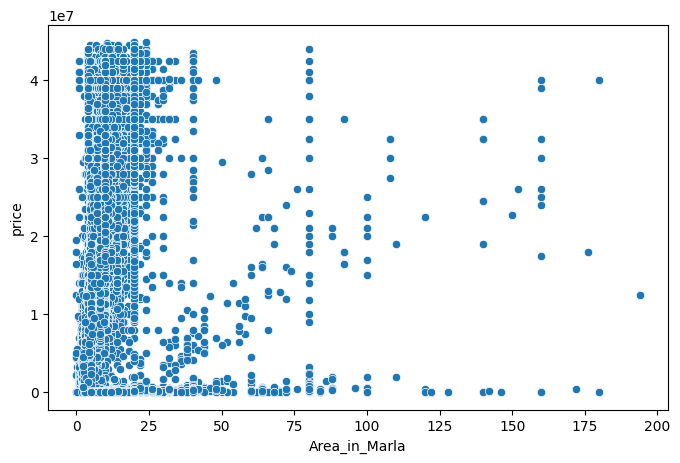

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Area_in_Marla', y='price')
plt.show()

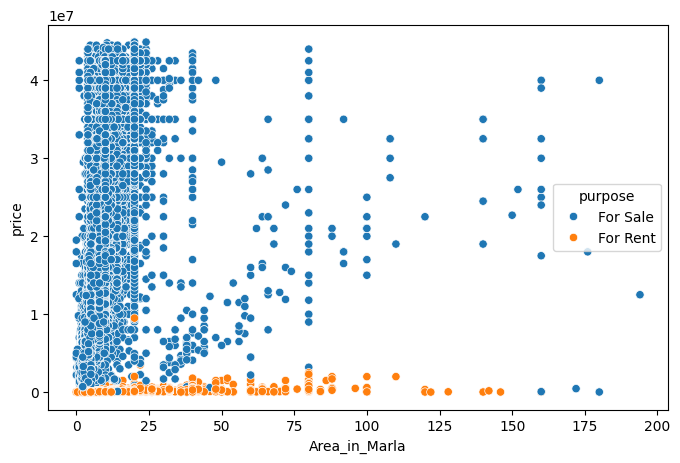

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Area_in_Marla', y='price', hue='purpose')
plt.show()

This shows how property price changes with area (in Marla). It helps us understand whether bigger properties tend to cost more, and whether this pattern differs between properties for sale and for rent.

## 2. Bar Plot (Numerical - Categorical)

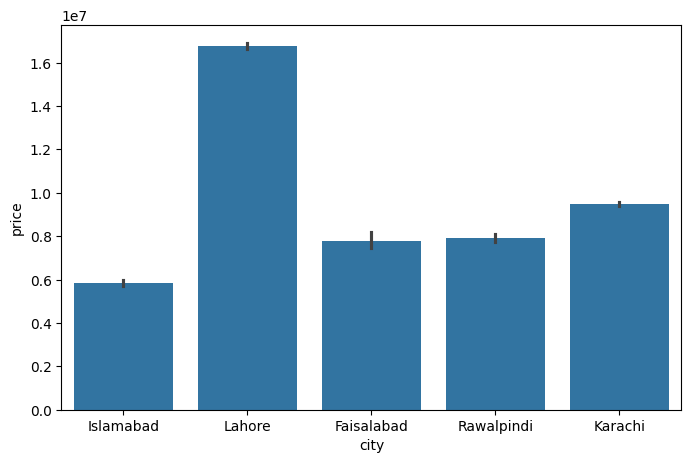

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='city', y='price')
plt.show()

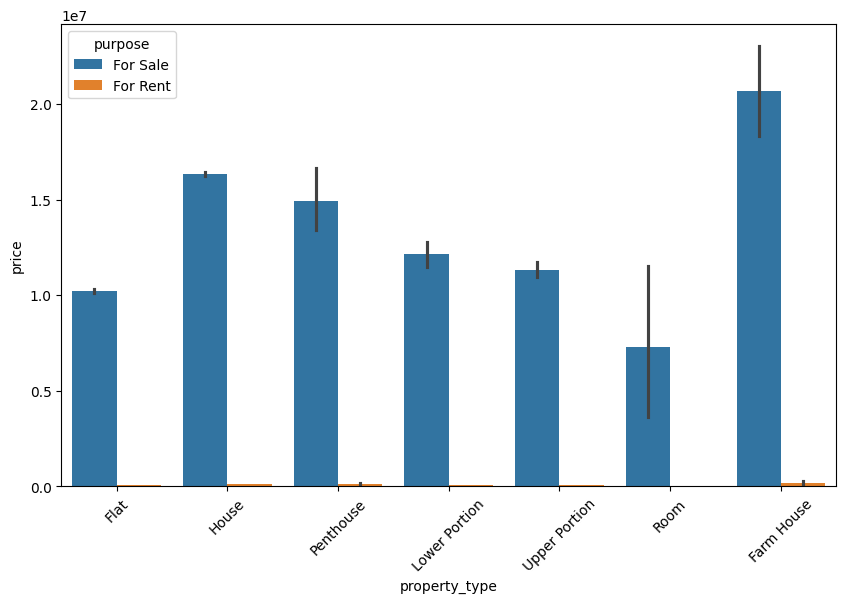

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='property_type', y='price', hue='purpose')
plt.xticks(rotation=45)
plt.show()

This shows the average price for each city and property type. It helps us understand which cities and property types tend to be more expensive.

## 3. Box Plot (Numerical - Categorical)

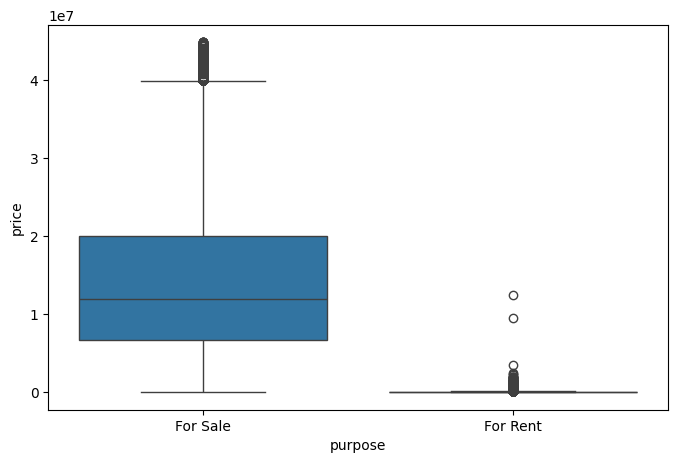

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='purpose', y='price')
plt.show()

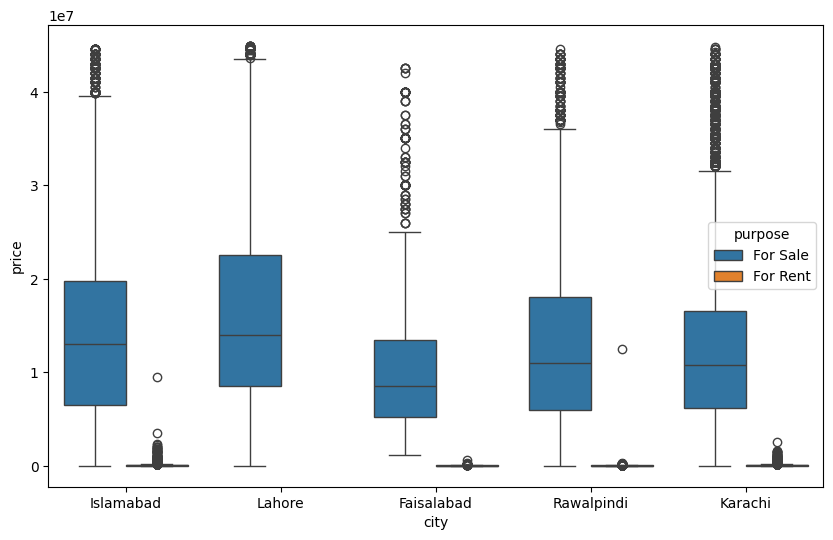

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city', y='price', hue='purpose')
plt.show()

This shows the spread and median of prices for each category, along with outliers. It helps us see how much prices vary within a city or purpose, not just the average.

## 4. Distplot (Numerical - Categorical)

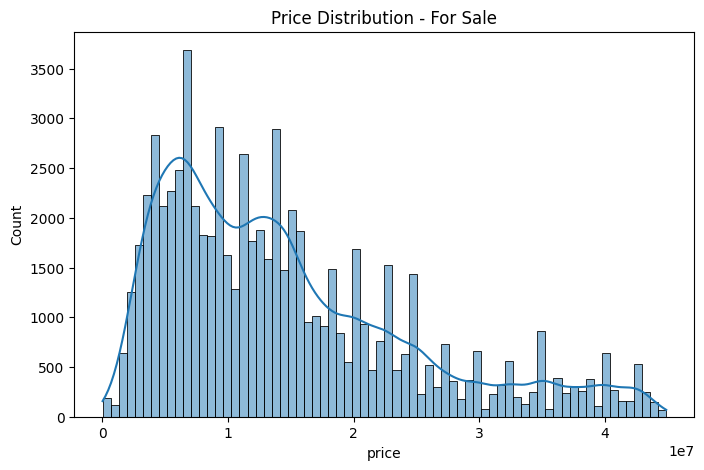

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['purpose'] == 'For Sale']['price'], kde=True)
plt.title('Price Distribution - For Sale')
plt.show()

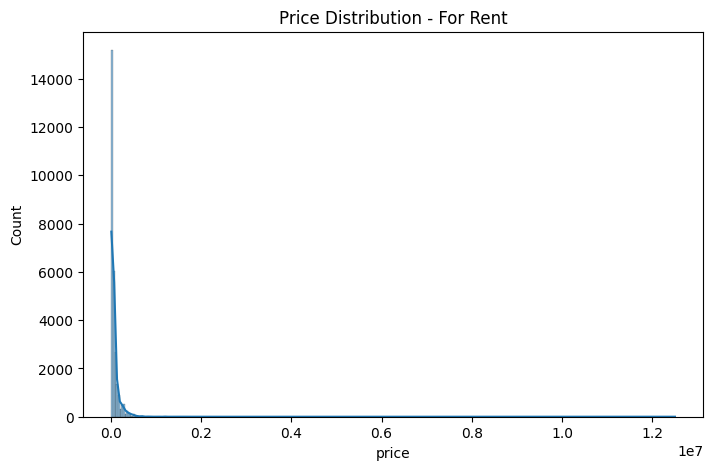

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['purpose'] == 'For Rent']['price'], kde=True)
plt.title('Price Distribution - For Rent')
plt.show()

This shows how prices are distributed for properties that are for sale versus for rent. It helps us understand if the two groups have very different price ranges.

## 5. HeatMap (Categorical - Categorical)

In [14]:
pd.crosstab(df['city'], df['purpose'])

purpose,For Rent,For Sale
city,,
Faisalabad,620,1611
Islamabad,13449,8794
Karachi,9856,27210
Lahore,0,26221
Rawalpindi,4627,7111


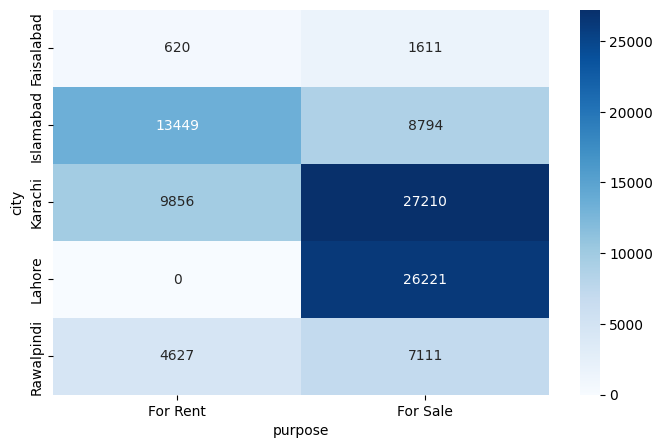

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(pd.crosstab(df['city'], df['purpose']), annot=True, fmt='d', cmap='Blues')
plt.show()

In [16]:
# Percentage of listings that are for rent vs for sale, within each city
pd.crosstab(df['city'], df['purpose'], normalize='index') * 100

purpose,For Rent,For Sale
city,,
Faisalabad,27.790229,72.209771
Islamabad,60.463966,39.536034
Karachi,26.590406,73.409594
Lahore,0.000000,100.000000
Rawalpindi,39.418981,60.581019


This shows how many listings fall into each city and purpose combination. It helps us understand whether renting or selling is more common in each city.

## 6. ClusterMap (Categorical - Categorical)

In [17]:
pd.crosstab(df['property_type'], df['purpose'])

purpose,For Rent,For Sale
property_type,,
Farm House,13,75
Flat,7275,19383
House,9147,49022
Lower Portion,4889,660
Penthouse,71,184
Room,229,12
Upper Portion,6928,1611


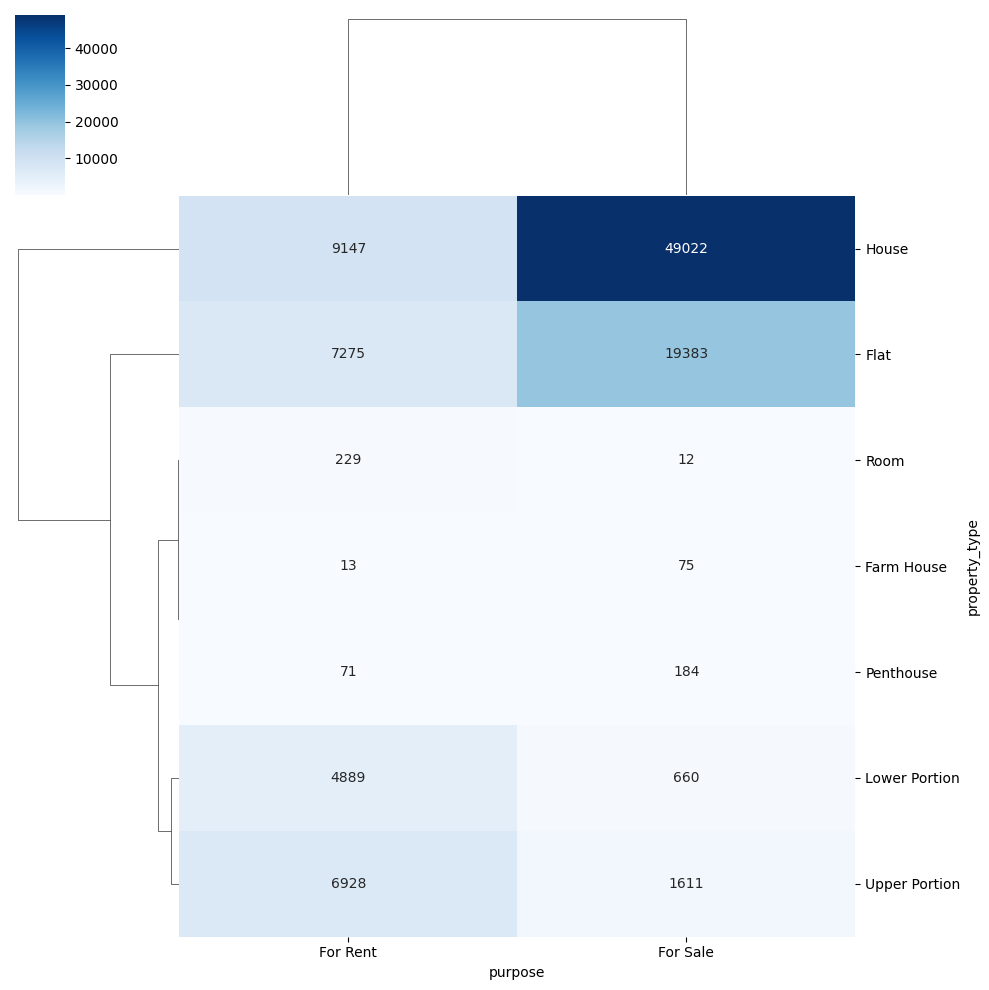

In [18]:
sns.clustermap(pd.crosstab(df['property_type'], df['purpose']), annot=True, fmt='d', cmap='Blues')
plt.show()

This groups similar property types and purposes together based on how alike their counts are. It helps us spot which property types behave similarly in terms of being for sale or for rent.

## 7. Pairplot

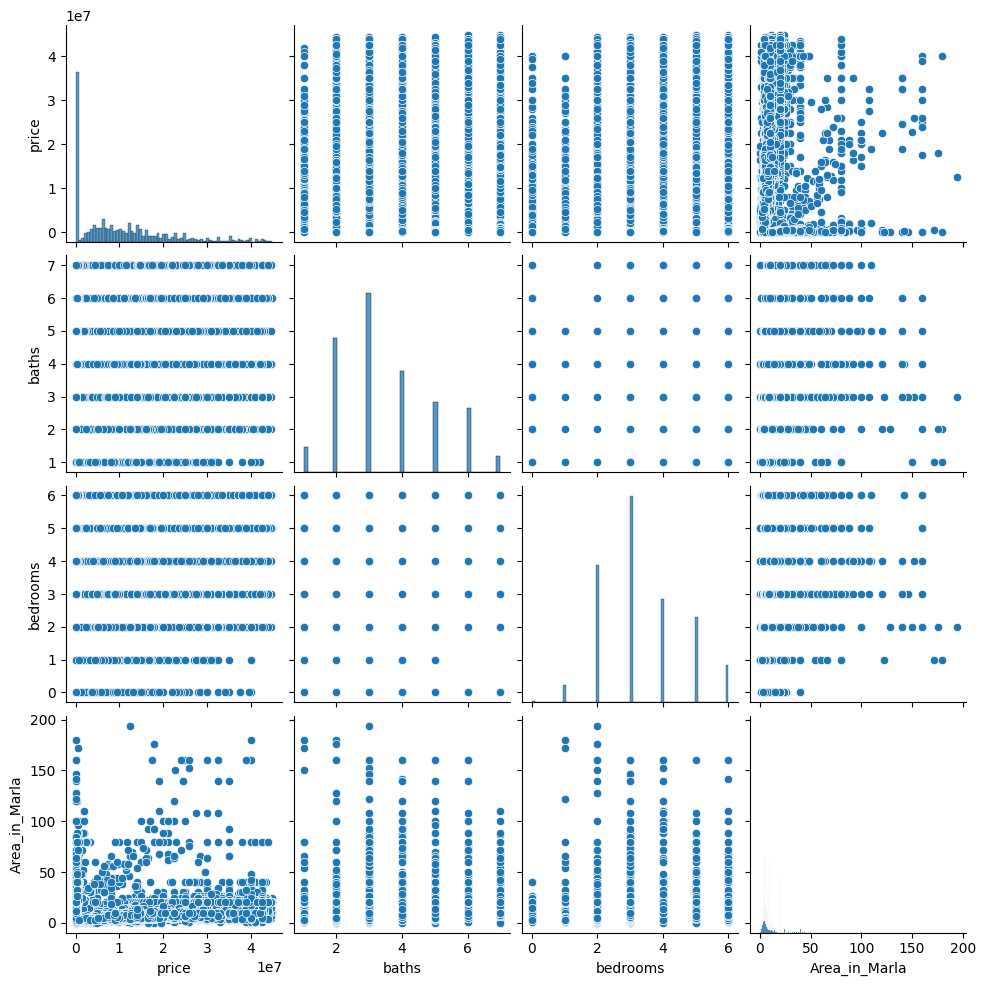

In [19]:
numeric_cols = ['price', 'baths', 'bedrooms', 'Area_in_Marla']
sns.pairplot(df[numeric_cols])
plt.show()

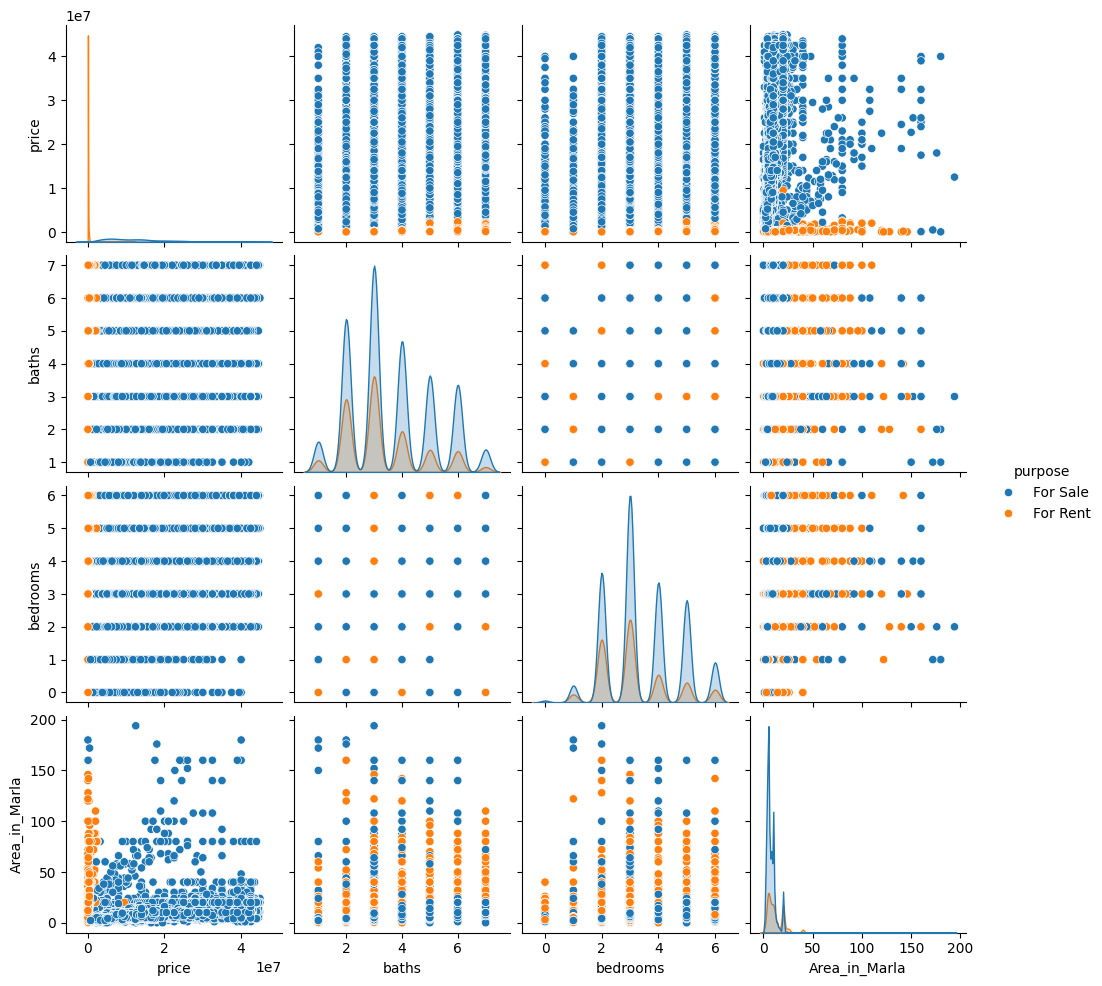

In [20]:
sns.pairplot(df[numeric_cols + ['purpose']], hue='purpose')
plt.show()

This shows the relationship between every pair of numerical columns at once. It helps us quickly spot which numerical variables move together, such as bedrooms and bathrooms.